**HON2200 Project 1**

In this notebook I will analyse data from the compas project.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read data from csv-file and print headers
data = pd.read_csv('compas-scores-two-years.csv')

heads = data.columns
print(heads)

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')


By running the code-block above you see a list of all the categories in the dataset. I will now make a new list of headers with the desired, relevant categories.

In [11]:
data = data[data["days_b_screening_arrest"] <= 30]
data = data[data["days_b_screening_arrest"] >= -30]
data = data[['compas_screening_date', 'sex', 'age', 'age_cat', 'race', 'decile_score', 'is_recid', 'is_violent_recid']]

print(data['race'])

0                  Other
1       African-American
2       African-American
5                  Other
6              Caucasian
              ...       
7209    African-American
7210    African-American
7211               Other
7212    African-American
7213            Hispanic
Name: race, Length: 6172, dtype: str


Now I will do a number of plots,
- how often specific groups of people (men, women, white, black) repeat crimes
- hvor ofte ulike grupperinger av mennesker (kvinner, menn, hvite og svarte) blir predikert av algoritmen til å begå straffbare handlinger i framtiden.
- hvor ofte ulike grupper fikk ulike risikoskårer.
- hvor ofte de som begikk nye straffbare hadlinger (og de som ikke gjorde det) fikk ulike risikoskårer, og hvordan dette ser ut hvis du kun ser på hvite eller svarte.

This is within two years (I think).

51.13067840704423
37.02127659574468
55.84251968503937
54.54545454545454
12.207324394636782
6.978723404255319
13.41732283464567
18.181818181818183


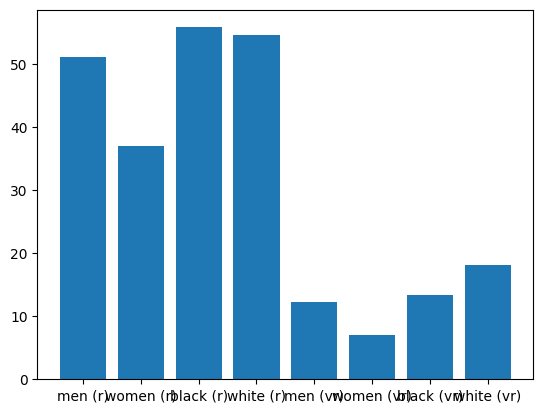

In [ ]:
men = data[data['sex'] == 'Male']
women = data[data['sex'] == 'Female']
black = data[data['race'] == 'African-American']
white = data[data['race'] == 'Native American']

# reciditive defendants
men_r = men[men['is_recid'] == 1]
women_r = women[women['is_recid'] == 1]
black_r = black[black['is_recid'] == 1]
white_r = white[white['is_recid'] == 1]

men_persentage_r = len(men_r) / len(men) * 100
women_persentage_r = len(women_r) / len(women) * 100
black_persentage_r = len(black_r) / len(black) * 100
white_persentage_r = len(white_r) / len(white) * 100


# violent reciditive defendants
men_vr = men[men['is_violent_recid'] == 1]
women_vr = women[women['is_violent_recid'] == 1]
black_vr = black[black['is_violent_recid'] == 1]
white_vr = white[white['is_violent_recid'] == 1]

men_persentage_vr = len(men_vr) / len(men) * 100
women_persentage_vr = len(women_vr) / len(women) * 100
black_persentage_vr = len(black_vr) / len(black) * 100
white_persentage_vr = len(white_vr) / len(white) * 100

percentages = np.array([men_persentage_r, women_persentage_r, black_persentage_r, white_persentage_r, men_persentage_vr, women_persentage_vr, black_persentage_vr, white_persentage_vr])
columns = np.array(['men (r)', 'women (r)', 'black (r)', 'white (r)', 'men (vr)', 'women (vr)', 'black (vr)', 'white (vr)'])

plt.bar(columns, percentages)
plt.show()


As we can see, the amount of black that commit new crimes, and white that 
commit new crimes are equal.